<a href="https://colab.research.google.com/github/IsaacFigNewton/CommitteeHearingDiscourseParser/blob/main/DH2024_DigitalDemocracy_Demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Accessing & working with the Digital Democracy Corpus: Comprehensive Proceedings of Four State Legislatures 2015-2018


This notebook will act as a guide for a person with minimal knowledge of coding to make use of the files and retrieve useful information from the corpus.


The dataset can be downloaded directly from this website: https://huggingface.co/datasets/iatpp/digitaldemocracy-2015-2018

This corpus is distributed under the cc-by-nc-sa-4.0 license. Please review before accessing. https://creativecommons.org/licenses/by-nc-sa/4.0/

Please cite as:

Khosmood, F., Dekhtyar, A., Ellwein, S., White, B., "The Digital Democracy Corpus: Comprehensive Proceedings of Four State Legislatures 2015-2018", Digital Humanities, Washington, DC, August 2024.

# Download files

The Digital Democracy Corpus can be downloaded from here: https://huggingface.co/datasets/iatpp/digitaldemocracy-2015-2018

In [1]:
from pathlib import Path
import subprocess
import zipfile
import os

#This is where the unzipped corpus file is stored
CORPUS_FILE_PATH = 'DH2024_Corpus_Release/'
corpus_dir = Path(CORPUS_FILE_PATH)
zip_path = Path("digitaldemocracy-2015-2018/DH2024_Corpus_Release.zip")
repo_dir = Path("digitaldemocracy-2015-2018")

# Clone repository if not present
if not repo_dir.is_dir():
    print("Corpus directory not found. Cloning repository...")
    subprocess.run(
        ["git", "clone", "https://huggingface.co/datasets/iatpp/digitaldemocracy-2015-2018"],
        check=True,
    )
    print("Repository cloned successfully.")

# Extract zip file if corpus directory doesn't exist
if not corpus_dir.is_dir():
    if zip_path.exists():
        print(f"Extracting {zip_path}...")
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall('.')
        print("Extraction complete.")
    else:
        print(f"Error: {zip_path} not found!")
else:
    print(f"Corpus already extracted at {corpus_dir}")

Corpus already extracted at DH2024_Corpus_Release


# Import and Config

In [2]:
from src.constants.constants import *
from src import HearingLoader, HearingTagger, ClassifierPipeline
from src.enums.SectionEnum import SectionEnum
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier

# Initialize the HearingLoader with the corpus path
loader = HearingLoader(corpus_path='DH2024_Corpus_Release/')
tagger = HearingTagger()

In [3]:
# discussion will contain all the information from bill CA_201720180AB10 in hearing id 51835
# 'CA_201720180AB10': ['51835',
#   '52298',
#   '52708',
#   '52856',
#   '53960',
#   '54363',
#   '54505']
hearing = loader.bill_discussion_info(51835, "CA_201720180AB10")
print(hearing)

State:		CA
Committee:	Assembly Standing Committee on Education
Bill:		CA_201720180AB10
Date:		2017-03-15


Transcript:
Patrick O'Donnell: [UNKNOWN]:
She'll be presenting AB 10, file item number one.


Cristina Garcia: [UNKNOWN]:
Thank you. Good afternoon Chair and members. I'm here presenting AB 10 would require vital menstrual products, pads, and tampons to be provided in school, colleges, shelters throughout the state. Menstrual products are a basic necessity similar to toilet paper. As early as the fourth grade young girls get their period and may not be prepared nor understand the natural changes of their bodies many of these young girls end up missing school three to five days a month on a regular basis, because they lack basic access to these products. No young girl should ever have to miss school because she does not have access to these basic health needs. For some young girls, access to these products is an additional barrier to their education. It's also loss of funding for s

# Load and Tag Hearings

In [4]:
hearings = loader.load_all_committee_hearings()
relevant_hearings = [h for h in hearings if h.bid != 'CA_NO BILL DISCUSSED']
print(len(hearings))
print(len(relevant_hearings))

invalid literal for int() with base 10: 'hid'
invalid literal for int() with base 10: 'hid'
invalid literal for int() with base 10: 'hid'
8218
7069


In [5]:
import random

# Set random seed for reproducibility
random.seed(42)

# Randomly sample 100 hearings
sampled_hearings = random.sample(relevant_hearings, 100)
sampled_hearings = [tagger(h) for h in sampled_hearings]
if sampled_hearings is None:
    raise ValueError("tagger returned no valid hearings from random sample")

# Build utterances dataframe from the sampled hearings using the new public method
# This automatically sorts by state, bid, hid, uid and fills missing values
utterances_df = tagger._build_utterances_dataframe(sampled_hearings)

# save it to a csv
utterances_df.to_csv('./utterances_sample.csv', index=False)

In [6]:
import pandas as pd

utterances_df = pd.read_csv('./utterances_sample.csv')
labeled_utterances_df = pd.read_csv('./utterances_sample_labeled.csv')

In [7]:
# Fill missing values in labeled data for train/test splits
utterances_df[TEXT_COL] = utterances_df[TEXT_COL].fillna("")
labeled_utterances_df[TEXT_COL] = labeled_utterances_df[TEXT_COL].fillna("")

utterances_df[TOKEN_COL] = utterances_df[TOKEN_COL].fillna(UNKNOWN)
labeled_utterances_df[TOKEN_COL] = labeled_utterances_df[TOKEN_COL].fillna(UNKNOWN)

for col in NUM_COLS:
  if col in utterances_df.columns:
    utterances_df[col] = utterances_df[col].fillna(0)
  if col in labeled_utterances_df.columns:
    labeled_utterances_df[col] = labeled_utterances_df[col].fillna(0)

for col in CAT_COLS:
  if col in utterances_df.columns:
    utterances_df[col] = utterances_df[col].fillna(UNKNOWN)
  if col in labeled_utterances_df.columns:
    labeled_utterances_df[col] = labeled_utterances_df[col].fillna(UNKNOWN)

In [8]:
for col in utterances_df.columns:
    print(f"{col}\t{utterances_df[col].isna().sum()}")

state	0
bid	0
hid	0
uid	0
pid	0
speaker.position	0
speaker.position.value	30
can_file_motions	0
is_presenter	0
relative_position	0
token_count	0
sent_count	0
mentions_speaker	0
mentions_bill	0
speech_act_cues	0
section_cues	0
section	2619
text	0


In [9]:
nontoken_feature_cols = [
    c for c in utterances_df.columns
    if c not in labeled_utterances_df.columns
]
labeled_utterances_df[nontoken_feature_cols] = utterances_df[nontoken_feature_cols]


In [10]:
labeled_utterances_df.head()

,state,bid,hid,uid,pid,speaker.position,section,text,speaker.position.value,can_file_motions,is_presenter,relative_position,token_count,sent_count,mentions_speaker,mentions_bill,speech_act_cues,section_cues
0,CA,CA_201520160AB2050,255341,0,55,PRESIDING_CHAIR,INTRO,ORG woman BILL_AUTHOR you have three matters i...,8.0,True,False,0.000000,83,5,1,1,OTHER,OTHER
1,CA,CA_201520160AB2050,255341,1,101330,BILL_AUTHOR,PRESENTATION,good morning mr chair and members thank you fo...,4.0,False,True,0.022727,373,18,0,1,OTHER,OTHER
2,CA,CA_201520160AB2050,255341,2,55,PRESIDING_CHAIR,PRESENTATION,that is correct what they've been doing we've ...,8.0,True,False,0.045455,24,3,0,0,OTHER,OTHER
3,CA,CA_201520160AB2050,255341,3,101330,BILL_AUTHOR,PRESENTATION,that's correct,4.0,False,True,0.068182,2,1,0,0,OTHER,OTHER
4,CA,CA_201520160AB2050,255341,4,55,PRESIDING_CHAIR,PRESENTATION,and this is plan step two I guess or new step two,8.0,True,False,0.090909,13,1,0,0,OTHER,OTHER


In [11]:
labeled_utterances_df['section'].value_counts()

section
PUBLIC_COMMENTS          743
LEGISLATOR_DISCUSSION    740
VOTE                     248
EXPERT_TESTIMONY         221
CLOSING_REMARKS          191
PRESENTATION             138
OTHER_HEARING            102
INTRO                     84
OTHER_PROCEDURAL          84
OTHER_NONPROCEDURAL       68
Name: count, dtype: int64

# Evaluation

## Config

In [12]:
from sklearn.model_selection import GroupShuffleSplit

splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.25,
    random_state=69,
)

In [13]:
# Create classifiers
lr_classifier = LogisticRegression(
    max_iter=2000,
    class_weight='balanced',
    solver='lbfgs'
)

mlp_classifier = MLPClassifier(
    hidden_layer_sizes=(10, 10),
    max_iter=2000,
    random_state=42,
    solver='adam'
)

# Create parsers with different classifiers
parser_lr = ClassifierPipeline(
    base_estimator=lr_classifier,
    masking=True,
    smoothing=False
)
parser_mlp = ClassifierPipeline(
    base_estimator=mlp_classifier,
    masking=True,
    smoothing=False
)

In [14]:
# Create a combined group identifier for bid+hid
labeled_utterances_df['hearing_group'] = labeled_utterances_df['bid'].astype(str) + '_' + labeled_utterances_df['hid'].astype(str)

train_idx, test_idx = next(
    splitter.split(
        labeled_utterances_df, 
        labeled_utterances_df['section'], 
        groups=labeled_utterances_df['hearing_group']
    )
)

train_df = labeled_utterances_df.iloc[train_idx].copy()
test_df = labeled_utterances_df.iloc[test_idx].copy()

# Sort by hearing_group and uid to match the order that predict() returns
train_df = train_df.sort_values(by=['hearing_group', 'uid']).reset_index(drop=True)
test_df = test_df.sort_values(by=['hearing_group', 'uid']).reset_index(drop=True)

print('Train rows:', len(train_df))
print('Test rows:', len(test_df))
print('Train hearings:', train_df['hearing_group'].nunique())
print('Test hearings:', test_df['hearing_group'].nunique())

Train rows: 2010
Test rows: 609
Train hearings: 75
Test hearings: 25


In [15]:
# Prepare train and test data
X_train = train_df[FEATURE_COLS + ["uid", "hearing_group"]]
y_train = train_df['section']

X_test = test_df[FEATURE_COLS + ["uid", "hearing_group"]]
y_test = test_df['section']

## Train models

In [16]:
for col in X_train.columns:
    print(f"{col}\t{X_train[col].isna().sum()}")

speaker.position	0
text	0
section_cues	0
speech_act_cues	0
relative_position	0
sent_count	0
token_count	0
mentions_speaker	0
mentions_bill	0
uid	0
hearing_group	0


In [17]:
# Train both models using HearingParser's train_model method
print("Training Logistic Regression model...")
parser_lr.fit(X_train, y_train)

print("Training MLP classifier model...")
parser_mlp.fit(X_train, y_train)

Training Logistic Regression model...
Training MLP classifier model...


## Evaluation Results

In [18]:
import numpy as np
from sklearn.metrics import classification_report

label_order = [s.value for s in list(SectionEnum)]

In [19]:
# X_test[:30]

In [20]:
# Evaluate Logistic Regression model
print("=" * 80)
print("LOGISTIC REGRESSION MODEL EVALUATION")
print("=" * 80)

pred_lr = parser_lr.predict(X_test)

print(classification_report(
    y_test,
    pred_lr,
    labels=label_order,
    digits=3,
))

LOGISTIC REGRESSION MODEL EVALUATION
                       precision    recall  f1-score   support

                INTRO      0.792     0.704     0.745        27
         PRESENTATION      0.690     0.714     0.702        28
LEGISLATOR_DISCUSSION      0.921     0.671     0.777       207
     EXPERT_TESTIMONY      0.568     0.700     0.627        60
      PUBLIC_COMMENTS      0.868     0.861     0.864       137
      CLOSING_REMARKS      0.767     0.717     0.742        46
                 VOTE      0.731     0.760     0.745        50
        OTHER_HEARING      0.206     0.241     0.222        29
     OTHER_PROCEDURAL      0.175     0.538     0.264        13
  OTHER_NONPROCEDURAL      0.154     0.333     0.211        12

             accuracy                          0.701       609
            macro avg      0.587     0.624     0.590       609
         weighted avg      0.765     0.701     0.723       609



In [21]:
# Evaluate MLP model
print("\n" + "=" * 80)
print("MLP CLASSIFIER MODEL EVALUATION")
print("=" * 80)

pred_mlp = parser_mlp.predict(X_test)

print(classification_report(
    y_test,
    pred_mlp,
    labels=label_order,
    digits=3,
))


MLP CLASSIFIER MODEL EVALUATION
                       precision    recall  f1-score   support

                INTRO      0.714     0.370     0.488        27
         PRESENTATION      0.440     0.786     0.564        28
LEGISLATOR_DISCUSSION      0.771     0.715     0.742       207
     EXPERT_TESTIMONY      0.529     0.450     0.486        60
      PUBLIC_COMMENTS      0.781     0.861     0.819       137
      CLOSING_REMARKS      0.688     0.478     0.564        46
                 VOTE      0.545     0.720     0.621        50
        OTHER_HEARING      0.318     0.241     0.275        29
     OTHER_PROCEDURAL      0.238     0.385     0.294        13
  OTHER_NONPROCEDURAL      0.400     0.333     0.364        12

             accuracy                          0.655       609
            macro avg      0.543     0.534     0.522       609
         weighted avg      0.667     0.655     0.652       609



## Confusion Matrix

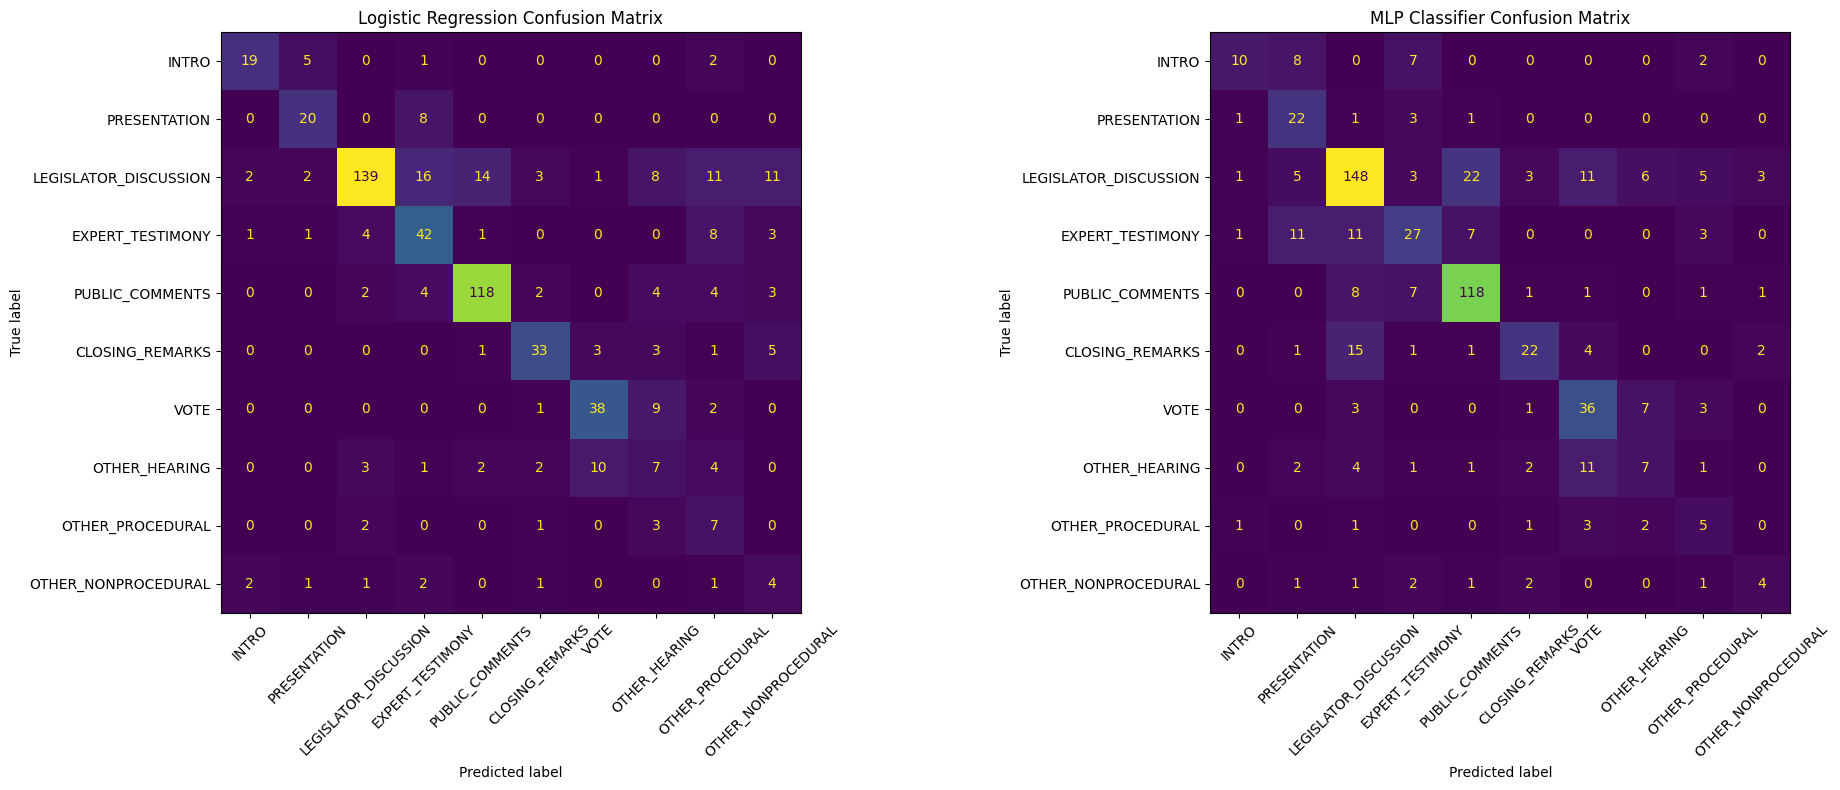

In [22]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# Filter to only labels present in test set
labels = [label for label in label_order if label in y_test.unique()]

# Create side-by-side confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Logistic Regression confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_test,
    pred_lr,
    labels=labels,
    xticks_rotation=45,
    ax=axes[0],
    colorbar=False,
)
axes[0].set_title('Logistic Regression Confusion Matrix')

# MLP confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_test,
    pred_mlp,
    labels=labels,
    xticks_rotation=45,
    ax=axes[1],
    colorbar=False,
)
axes[1].set_title('MLP Classifier Confusion Matrix')

plt.tight_layout()
plt.show()

In [23]:
# Group test data by hearing for individual hearing predictions
test_hearings_grouped = {}
for hearing_group in test_df['hearing_group'].unique():
    hearing_data = test_df[test_df['hearing_group'] == hearing_group].sort_values('uid')
    bid = hearing_data['bid'].iloc[0]
    hid = hearing_data['hid'].iloc[0]
    test_hearings_grouped[hearing_group] = {
        'bid': bid,
        'hid': hid,
        'data': hearing_data[FEATURE_COLS + ['uid', 'hearing_group']]
    }

In [24]:
sample_hearing_id, sample_hearing_data = list(test_hearings_grouped.items())[0]

sample_hearing = None
for h in sampled_hearings:
    if h.bid == sample_hearing_data['bid'] and h.hid == sample_hearing_data['hid']:
        sample_hearing = h
        break

# Use the new ClassifierPipeline predict interface
labels_lr = parser_lr.predict(sample_hearing_data['data'])

print("Logistic Regression predictions:")
print(labels_lr)

print("\n" + "=" * 80 + "\n")

# Use the new ClassifierPipeline predict interface
labels_mlp = parser_mlp.predict(sample_hearing_data['data'])

print("MLP Classifier predictions:")
print(labels_mlp)

Logistic Regression predictions:
['PRESENTATION' 'EXPERT_TESTIMONY' 'EXPERT_TESTIMONY' 'OTHER_PROCEDURAL'
 'EXPERT_TESTIMONY' 'PUBLIC_COMMENTS' 'CLOSING_REMARKS' 'OTHER_PROCEDURAL'
 'LEGISLATOR_DISCUSSION' 'VOTE' 'OTHER_HEARING' 'CLOSING_REMARKS'
 'OTHER_HEARING' 'OTHER_HEARING' 'CLOSING_REMARKS']


MLP Classifier predictions:
['PRESENTATION' 'EXPERT_TESTIMONY' 'EXPERT_TESTIMONY' 'OTHER_PROCEDURAL'
 'EXPERT_TESTIMONY' 'PUBLIC_COMMENTS' 'CLOSING_REMARKS' 'OTHER_PROCEDURAL'
 'LEGISLATOR_DISCUSSION' 'VOTE' 'OTHER_HEARING' 'VOTE' 'OTHER_HEARING'
 'VOTE' 'CLOSING_REMARKS']


In [25]:
special_hearing = None
for h in sampled_hearings:
  if h.bid == 'CA_201720180AB2721':
    special_hearing = h
    break

Note: special case of Chairman presenting to someone else: Bill ID CA_201720180SB1293

Special kind of bill discussion: CA_201720180AB1708
Case where you have to use handoff cue: CA_201720180AB2721
CA_201720180SCR159

# Sanity Checks

In [26]:
def pprint_hearing_labels(hearing, hearing_df, labeled_utterances_df, parser, model_name=""):
  """Print formatted transcript with predicted section labels.
  
  Args:
      hearing: The hearing object to print
      hearing_df: DataFrame with utterance features and 'hearing_group' column
      labeled_utterances_df: DataFrame with ground truth labels
      parser: ClassifierPipeline instance with trained model
      model_name: Name of the model for display purposes
  """
  # Predict using the new interface - just pass the DataFrame with hearing_group
  pred_labels = parser.predict(hearing_df)
  
  # Filter labeled_utterances_df for this specific hearing
  hearing_labels = labeled_utterances_df[
    (labeled_utterances_df['bid'] == hearing.bid) & 
    (labeled_utterances_df['hid'] == hearing.hid)
  ].sort_values('uid')
  
  true_labels = hearing_labels['section'].values

  print()
  if model_name:
    print(f"Model: {model_name}")
  print(f"State:\t\t{hearing.state}")
  print(f"Committee:\t{hearing.cname}")
  print(f"Bill:\t\t{hearing.bid}")
  print(f"Date:\t\t{hearing.hearing_date.strftime('%Y-%m-%d')}")
  print()
  print("Transcript:")
  for i, contribution in enumerate(hearing.utterances):
    speaker = hearing.speakers[contribution.pid]
    print(f'Predicted label:\t[{pred_labels[i] if i < len(pred_labels) else "UNKNOWN"}]')
    print(f'True label:\t\t[{true_labels[i] if i < len(true_labels) else "UNKNOWN"}]')
    first_name = speaker.first_name or "UNKNOWN"
    last_name = speaker.last_name or "UNKNOWN"
    role = "UNKNOWN"
    if speaker.speaker_position:
      role = speaker.speaker_position.name
    name = f"{first_name} {last_name} [{role}]:"
    print(f"{name:<20}")
    print(f"\t{contribution.text}")
    print()
  print()

In [27]:
print("=" * 80)
print("LOGISTIC REGRESSION MODEL")
print("=" * 80)
pprint_hearing_labels(
    sample_hearing,
    sample_hearing_data['data'],
    labeled_utterances_df, parser_lr, "Logistic Regression")

print("\n" + "=" * 80)
print("MLP CLASSIFIER MODEL")
print("=" * 80)
pprint_hearing_labels(
    sample_hearing,
    sample_hearing_data['data'],
    labeled_utterances_df, parser_mlp, "MLP Classifier")

LOGISTIC REGRESSION MODEL

Model: Logistic Regression
State:		CA
Committee:	Senate Standing Committee on Elections and Constitutional Amendments
Bill:		CA_201720180AB1013
Date:		2018-05-15

Transcript:
Predicted label:	[PRESENTATION]
True label:		[PRESENTATION]
Evan Low [BILL_AUTHOR]:
	this is ORG bill 1013 with respect to allowing voters who might have disabilities to be able to vote remotely I respectfully ask for your aye vote

Predicted label:	[EXPERT_TESTIMONY]
True label:		[EXPERT_TESTIMONY]
Henry Stern [PRESIDING_CHAIR]:
	thank you witnesses in support

Predicted label:	[EXPERT_TESTIMONY]
True label:		[EXPERT_TESTIMONY]
Unidentified Speaker [UNKNOWN]:
	would you like to sit at the table or want to sit up here by the

Predicted label:	[OTHER_PROCEDURAL]
True label:		[EXPERT_TESTIMONY]
Henry Stern [PRESIDING_CHAIR]:
	good afternoon

Predicted label:	[EXPERT_TESTIMONY]
True label:		[EXPERT_TESTIMONY]
Jeff Tom [EXPERT]:  
	good afternoon mr chair and members NONLEGISLATOR representi